In [1]:
# Import required libraries for data manipulation, visualization, preprocessing, and modeling.
# WHY & HOW:
# - pandas/numpy: Essential for data loading, grid creation, aggregation, and mathematical operations.
# - matplotlib/seaborn: Used to construct feature importance and residual diagnostic plots.
# - train_test_split: Splits our dataset into training and test sets to evaluate performance.
# - RandomizedSearchCV: Used for computationally efficient hyperparameter tuning of the Random Forest model.
# - StandardScaler: Standardizes continuous features to a standard normal distribution.
# - r2_score: The evaluation metric (R-squared) to evaluate how well our model fits the test data.
# - RandomForestRegressor: Our main regression algorithm that fits multiple decision trees and averages predictions.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load the raw traffic/demand dataset.
# WHY & HOW:
# - We read the CSV file containing the features and target variable (demand).
# - df.head() allows us to inspect the first 5 rows and verify correct file loading.
df = pd.read_csv('C:/Users/ridha/Desktop/train.csv')
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [3]:
# Preprocess timestamps and compute chronological lag features.
# WHY:
# - Timestamps are strings (e.g., "1:15") and must be converted to float hours to represent continuity.
# - Spatio-temporal data can have missing records for some coordinates (geohashes) or times. If we compute lags 
#   directly on raw records, we risk associating a row with an incorrect historical row. 
# HOW:
# - We define 'convert_timestamp' to convert hour:minute strings to continuous numerical values.
# - We build a complete cartesian product grid of all unique geohashes, days, and time intervals.
# - We merge the original df into the grid, filling missing demand observations with 0.0 (inactive states).
# - We compute chronological lags (1 to 4 steps back) by grouping by geohash and shifting target demand.
# - Finally, we filter back to 'is_original == 1' to keep only the rows that were present in our original dataset,
#   dropping the synthetic helper rows but retaining the correct lag values.
# 1. Preprocess timestamp to continuous hours
def convert_timestamp(val):
    h, m = map(int, str(val).split(':'))
    return h + m / 60.0

df['timestamp_hours'] = df['timestamp'].apply(convert_timestamp)

# 2. Build full grid to compute lags without gaps
geohashes = df['geohash'].unique()
days = [48, 49]
timestamps = df['timestamp_hours'].unique()
timestamps.sort()

grid = pd.MultiIndex.from_product([geohashes, days, timestamps], names=['geohash', 'day', 'timestamp_hours']).to_frame().reset_index(drop=True)
df['is_original'] = 1

grid_df = grid.merge(df, on=['geohash', 'day', 'timestamp_hours'], how='left')
grid_df['demand'] = grid_df['demand'].fillna(0.0)
grid_df = grid_df.sort_values(by=['geohash', 'day', 'timestamp_hours']).reset_index(drop=True)

# Compute chronological lags
grid_df['demand_lag_1'] = grid_df.groupby('geohash')['demand'].shift(1)
grid_df['demand_lag_2'] = grid_df.groupby('geohash')['demand'].shift(2)
grid_df['demand_lag_3'] = grid_df.groupby('geohash')['demand'].shift(3)
grid_df['demand_lag_4'] = grid_df.groupby('geohash')['demand'].shift(4)

df_features = grid_df[grid_df['is_original'] == 1].copy()
df_features = df_features.drop(columns=['is_original'])

lag_cols = ['demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_4']
df_features[lag_cols] = df_features[lag_cols].fillna(0.0)
df_features.head()

,geohash,day,timestamp_hours,Index,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,demand_lag_1,demand_lag_2,demand_lag_3,demand_lag_4
4,qp02yc,48,1.00,2911.0,1:0,0.005397,Residential,3.0,Allowed,Yes,11.299877,Rainy,0.000000,0.0,0.000000,0.000000
10,qp02yc,48,2.50,8010.0,2:30,0.012944,Residential,2.0,Not Allowed,Yes,32.142120,Sunny,0.000000,0.0,0.000000,0.000000
11,qp02yc,48,2.75,8905.0,2:45,0.025961,Residential,1.0,Not Allowed,No,15.811063,Foggy,0.012944,0.0,0.000000,0.000000
14,qp02yc,48,3.50,11570.0,3:30,0.026422,Residential,2.0,Not Allowed,Yes,17.297484,Foggy,0.000000,0.0,0.025961,0.012944
26,qp02yc,48,6.50,22536.0,6:30,0.008387,Residential,1.0,Not Allowed,No,11.435670,Rainy,0.000000,0.0,0.000000,0.000000


In [4]:
# Handle missing data in categorical and numerical columns.
# WHY:
# - ML algorithms (including Random Forest in sklearn) cannot handle null/NaN values directly.
# HOW:
# - We impute missing values for categorical columns ('RoadType', 'Weather') using their mode (most common value).
# - We impute missing 'Temperature' using the median to avoid outlier bias.
# - Calling df_features.isnull().sum() allows us to verify that all features are successfully imputed.
df_features['RoadType'] = df_features['RoadType'].fillna(df_features['RoadType'].mode()[0])
df_features['Weather'] = df_features['Weather'].fillna(df_features['Weather'].mode()[0])
df_features['Temperature'] = df_features['Temperature'].fillna(df_features['Temperature'].median())
df_features.isnull().sum()

geohash            0
day                0
timestamp_hours    0
Index              0
timestamp          0
demand             0
RoadType           0
NumberofLanes      0
LargeVehicles      0
Landmarks          0
Temperature        0
Weather            0
demand_lag_1       0
demand_lag_2       0
demand_lag_3       0
demand_lag_4       0
dtype: int64

In [5]:
# Encode time of day as cyclical features using sine and cosine transformations.
# WHY:
# - Hours are linear (0 to 23.75), but time is cyclical. Standard encoding makes 23:45 and 00:00 numerically distant, 
#   even though they are chronologically adjacent.
# HOW:
# - We project the hours onto a unit circle using 2 * pi * hours / 24. This projects timestamps to sine and cosine waves 
#   which accurately represent adjacency and circular progression of time.
df_features['timestamp_sin'] = np.sin(2 * np.pi * df_features['timestamp_hours'] / 24.0)
df_features['timestamp_cos'] = np.cos(2 * np.pi * df_features['timestamp_hours'] / 24.0)
df_features[['timestamp_hours', 'timestamp_sin', 'timestamp_cos']].head()

,timestamp_hours,timestamp_sin,timestamp_cos
4,1.00,0.258819,0.965926
10,2.50,0.608761,0.793353
11,2.75,0.659346,0.751840
14,3.50,0.793353,0.608761
26,6.50,0.991445,-0.130526


In [6]:
# Encode categorical columns into numerical values.
# WHY:
# - Machine learning models require numerical inputs.
# HOW:
# - We explicitly map binary text fields ('Landmarks' and 'LargeVehicles') to 1/0.
# - We use pd.get_dummies to one-hot encode multi-category features ('RoadType' and 'Weather').
# - drop_first=True is used to eliminate collinearity (the dummy variable trap) by dropping one redundant reference level.
df_features['Landmarks'] = df_features['Landmarks'].map({'Yes': 1, 'No': 0})
df_features['LargeVehicles'] = df_features['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0})
df_features = pd.get_dummies(df_features, columns=['RoadType', 'Weather'], drop_first=True, dtype=int)
df_features.head()

,geohash,day,timestamp_hours,Index,timestamp,demand,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,demand_lag_2,demand_lag_3,demand_lag_4,timestamp_sin,timestamp_cos,RoadType_Residential,RoadType_Street,Weather_Rainy,Weather_Snowy,Weather_Sunny
4,qp02yc,48,1.00,2911.0,1:0,0.005397,3.0,1,1,11.299877,...,0.0,0.000000,0.000000,0.258819,0.965926,1,0,1,0,0
10,qp02yc,48,2.50,8010.0,2:30,0.012944,2.0,0,1,32.142120,...,0.0,0.000000,0.000000,0.608761,0.793353,1,0,0,0,1
11,qp02yc,48,2.75,8905.0,2:45,0.025961,1.0,0,0,15.811063,...,0.0,0.000000,0.000000,0.659346,0.751840,1,0,0,0,0
14,qp02yc,48,3.50,11570.0,3:30,0.026422,2.0,0,1,17.297484,...,0.0,0.025961,0.012944,0.793353,0.608761,1,0,0,0,0
26,qp02yc,48,6.50,22536.0,6:30,0.008387,1.0,0,0,11.435670,...,0.0,0.000000,0.000000,0.991445,-0.130526,1,0,1,0,0


In [7]:
# Split the data into features (X) and target label (y), then segment into training and test datasets.
# WHY:
# - Training and evaluating on the same dataset leads to overfitting.
# - We drop columns that are either labels (demand) or non-predictive identifiers (Index, raw timestamp).
# HOW:
# - y represents 'demand', X represents the remaining engineered features.
# - We split the dataset into 80% training and 20% validation.
# - A fixed random_state (42) ensures the train-test split is identical across runs.
X = df_features.drop(columns=['demand', 'Index', 'timestamp'])
y = df_features['demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((61839, 18), (15460, 18))

In [8]:
# Encode high-cardinality geographical variable 'geohash' using target encoding.
# WHY:
# - 'geohash' has too many unique values for one-hot encoding, which would cause an exponential increase in feature dimensions.
# - Target encoding maps each geohash to its historical mean demand, capturing geographical demand patterns effectively.
# HOW:
# - To prevent data leakage, we compute mean target values *only* on the training set (y_train grouped by X_train['geohash']).
# - We map these computed means to both training and test sets.
# - Any unseen geohashes in the test set are filled with the global mean of y_train.
# - We drop the original 'geohash' text column.
geohash_means = y_train.groupby(X_train['geohash']).mean()
global_mean = y_train.mean()

X_train['geohash_encoded'] = X_train['geohash'].map(geohash_means).fillna(global_mean)
X_test['geohash_encoded'] = X_test['geohash'].map(geohash_means).fillna(global_mean)

X_train = X_train.drop(columns=['geohash'])
X_test = X_test.drop(columns=['geohash'])
X_train.head()

,day,timestamp_hours,NumberofLanes,LargeVehicles,Landmarks,Temperature,demand_lag_1,demand_lag_2,demand_lag_3,demand_lag_4,timestamp_sin,timestamp_cos,RoadType_Residential,RoadType_Street,Weather_Rainy,Weather_Snowy,Weather_Sunny,geohash_encoded
123910,48,17.50,2.0,0,1,29.800670,0.196254,0.234446,0.162193,0.133405,-0.991445,-0.130526,1,0,0,0,1,0.111958
137295,48,3.75,2.0,0,1,10.074079,0.170174,0.184543,0.238454,0.150633,0.831470,0.555570,1,0,1,0,0,0.221508
11139,48,0.75,2.0,0,1,16.909279,0.023922,0.027099,0.019981,0.000000,0.195090,0.980785,1,0,0,0,0,0.043339
113149,48,15.25,1.0,0,0,24.650854,0.078818,0.024011,0.076043,0.055838,-0.751840,-0.659346,1,0,0,0,1,0.096147
27094,48,5.50,1.0,0,0,25.908078,0.081946,0.075168,0.164115,0.114288,0.991445,0.130526,1,0,0,0,1,0.083887


In [9]:
# Perform Feature Scaling (Standardization) on continuous variables.
# WHY:
# - Standardizing values so they have a mean of 0 and variance of 1 improves model robustness and makes comparisons easier.
# HOW:
# - We fit the StandardScaler on X_train to learn the mean and standard deviation of each continuous column.
# - We then transform both X_train and X_test using these learned parameters to avoid lookahead/leakage bias.
continuous_cols = ['day', 'timestamp_hours', 'timestamp_sin', 'timestamp_cos', 'NumberofLanes', 'Temperature', 'geohash_encoded', 'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_4']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])
X_train_scaled.head()

,day,timestamp_hours,NumberofLanes,LargeVehicles,Landmarks,Temperature,demand_lag_1,demand_lag_2,demand_lag_3,demand_lag_4,timestamp_sin,timestamp_cos,RoadType_Residential,RoadType_Street,Weather_Rainy,Weather_Snowy,Weather_Sunny,geohash_encoded
123910,-0.335757,1.165574,-0.015451,0,1,1.847120,0.731166,1.012598,0.516278,0.325203,-1.874680,-0.234904,1,0,0,0,1,0.150010
137295,-0.335757,-0.836398,-0.015451,0,1,-0.875202,0.548567,0.662277,1.052983,0.446845,1.028660,0.674530,1,0,1,0,0,1.071688
11139,-0.335757,-1.273192,-0.015451,0,1,0.068074,-0.475418,-0.442987,-0.484570,-0.616734,0.015104,1.238160,1,0,0,0,0,-0.427307
113149,-0.335757,0.837979,-1.121316,0,0,1.136432,-0.091059,-0.464662,-0.090023,-0.222475,-1.493063,-0.935865,1,0,0,0,1,0.016983
27094,-0.335757,-0.581601,-1.121316,0,0,1.309932,-0.069159,-0.105540,0.529805,0.190224,1.283451,0.111126,1,0,0,0,1,-0.086167


In [10]:
# Train and evaluate a baseline Random Forest Regressor.
# WHY:
# - Establishes a reference score (R-squared) to measure how well the default parameters perform.
# HOW:
# - We instantiate the regressor with default 100 estimators and n_jobs=-1 (parallel processor usage).
# - We fit the model on our standardized training features and predict on test features, scoring the predictions.
# Baseline Random Forest
print("Training Baseline Random Forest Model...")
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train_scaled, y_train)
rf_pred = rf_base.predict(X_test_scaled)
rf_score = r2_score(y_test, rf_pred)
print(f"Baseline Random Forest R2: {rf_score:.4f}")

Training Baseline Random Forest Model...


Baseline Random Forest R2: 0.9623


In [11]:
# Fine-tune the Random Forest hyperparameters to optimize performance.
# WHY:
# - Default model parameters are not guaranteed to be optimal for our dataset.
# - Tuning on the entire dataset is computationally expensive and slow.
# HOW:
# - We subset 10% of the training set for search efficiency.
# - We set up a parameter grid for randomized search cross-validation (depth, trees, split minimums, feature counts).
# - RandomizedSearchCV randomly samples 10 configurations, validating with 3-fold cross validation.
# - We retrieve the optimal hyperparameters, retrain the model on the full training set, and evaluate on the test set.
# Tune Random Forest using RandomizedSearchCV on a 10% subset
print("Tuning Random Forest Hyperparameters...")
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train, train_size=0.1, random_state=42
)

rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 0.8, None]
}

rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_random_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_sample, y_train_sample)
print(f"Best Parameters found for Random Forest: {rf_random_search.best_params_}")

# Train the final Random Forest model using the best found hyperparameters
print("Training final tuned Random Forest model on full dataset...")
best_rf = rf_random_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)
tuned_rf_pred = best_rf.predict(X_test_scaled)
tuned_rf_score = r2_score(y_test, tuned_rf_pred)
print(f"Tuned Random Forest R2: {tuned_rf_score:.4f}")

Tuning Random Forest Hyperparameters...


Best Parameters found for Random Forest: {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 0.8, 'max_depth': None}
Training final tuned Random Forest model on full dataset...


Tuned Random Forest R2: 0.9631


C:\Users\ridha\AppData\Local\Temp\ipykernel_14020\1658437761.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis')


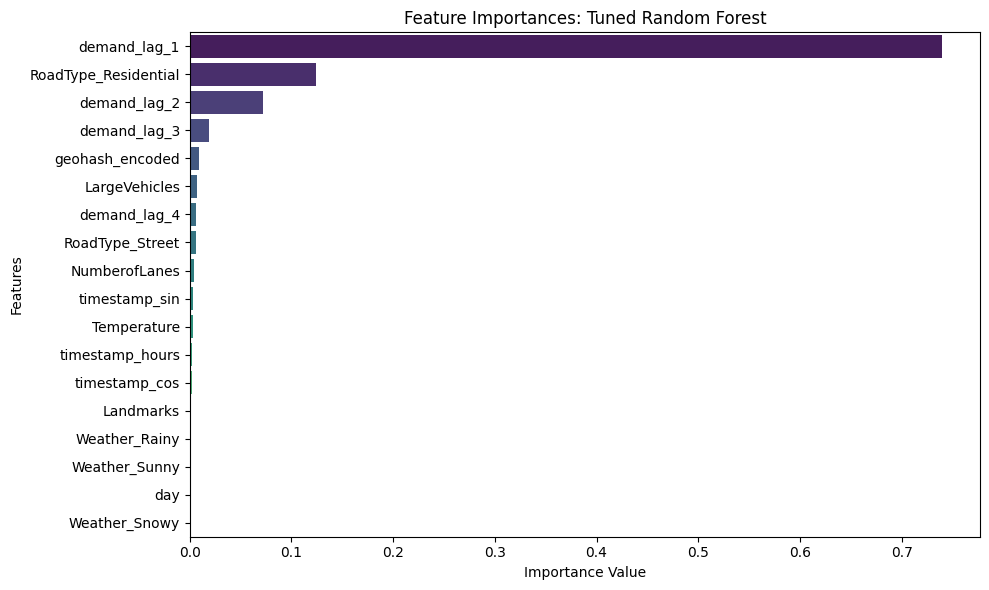

In [12]:
# Plot feature importance values of the final tuned model.
# WHY:
# - Visualizing which variables drive predictions helps explain model decisions and patterns in traffic demand.
# HOW:
# - We retrieve 'feature_importances_' from the trained tree model, sort them, and render a horizontal bar plot.
# Visualize Feature Importances of Tuned Random Forest
rf_importances = best_rf.feature_importances_
feature_names = X_train_scaled.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis')
plt.title('Feature Importances: Tuned Random Forest')
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

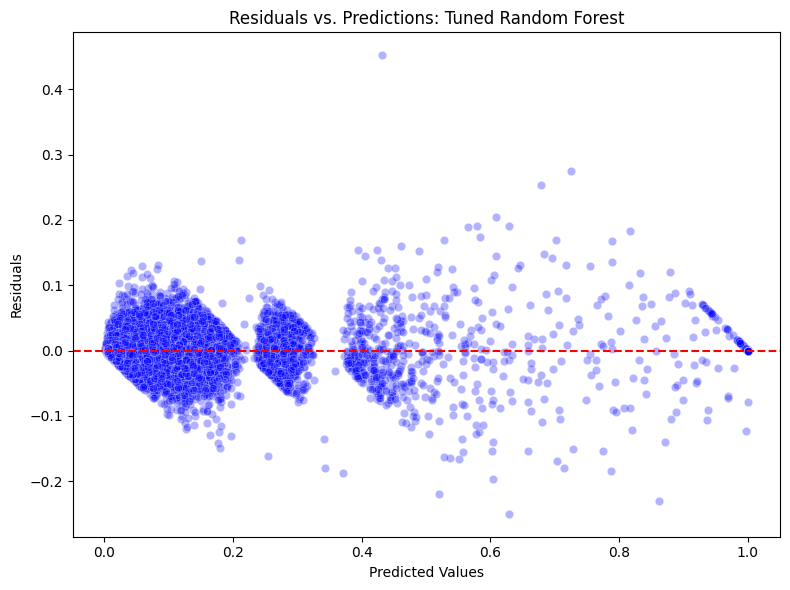

In [13]:
# Generate a residual diagnostic plot.
# WHY:
# - Plotting residuals (actual demand - predicted demand) vs predicted values checks for systematic bias or heteroscedasticity.
# HOW:
# - Subtract predicted values from actual test labels.
# - Construct a scatter plot of residuals around the zero error line (red dashed line) to visualize error distribution.
# Residual Diagnostics Plot
rf_residuals = y_test - tuned_rf_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=tuned_rf_pred, y=rf_residuals, alpha=0.3, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predictions: Tuned Random Forest')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()